✅ Faces loaded: 1


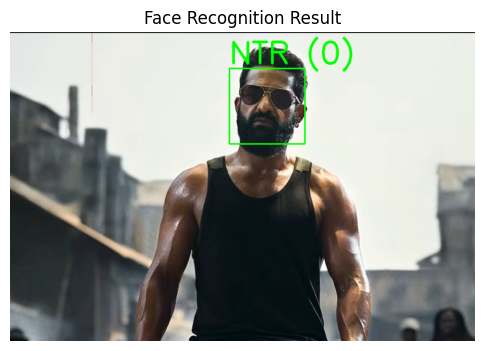

In [7]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Face Detection
def detect_face(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Using the default frontal face classifier
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    )
    # Adjusted sensitivity
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4)
    if len(faces) == 0:
        return None, None
    (x, y, w, h) = faces[0]
    return gray[y:y+h, x:x+w], faces[0]

# 2. Prepare Training Data
def prepare_training_data_from_paths(image_paths, input_labels):
    faces = []
    labels = []
    for i, image_path in enumerate(image_paths):
        image = cv2.imread(image_path)
        if image is None:
            print(f"Warning: Could not read image '{image_path}'. Skipping.")
            continue
        face, rect = detect_face(image)
        if face is not None:
            faces.append(face)
            labels.append(input_labels[i])
        else:
            print(f"Warning: No face detected in '{image_path}'. Skipping.")
    return faces, labels

# 3. Training Setup
subjects = ["", "NTR", "NTR1"]
training_image_paths = ["ntr.png", "ntr1.png"]
training_labels = [1, 2] 

faces, labels = prepare_training_data_from_paths(training_image_paths, training_labels)

if len(faces) == 0:
    print("No valid training faces found.")
else:
    print(f"✅ Faces loaded: {len(faces)}")
    face_recognizer = cv2.face.LBPHFaceRecognizer_create()
    face_recognizer.train(faces, np.array(labels))

    # 4. TESTING
    # Changed test_image_path to use 'ntr.png' since we know it's in your folder
    test_image_path = "ntr.png" 
    
    img = cv2.imread(test_image_path)

    if img is not None:
        face, rect = detect_face(img)
        if face is not None:
            label, confidence = face_recognizer.predict(face)
            label_text = subjects[label] if label < len(subjects) else "Unknown"
            
            (x, y, w, h) = rect
            cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(img, f"{label_text} ({int(confidence)})", (x, y - 10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 2.0, (0, 255, 0), 3, cv2.LINE_AA)
            
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(6, 6))
            plt.imshow(img_rgb)
            plt.axis("off")
            plt.title("Face Recognition Result")
            plt.show()
        else:
            print("No face detected in test image.")
    else:
        print("Test image not found.")